<b> Ejercicio de calidad de cotizaciones y relaciones entre strikes, usando tres cadenas de opciones SPY. </b>


<b> Pregunta: </b> Para opciones del mismo tipo y vencimiento, ¿cuántas aparentes inconsistencias entre strikes desaparecen al pasar de precios medios a bid/ask?

Elige tres fechas ya archivadas: una tranquila, una de alta volatilidad y otra reciente.

-  En cada una, toma calls y puts de un vencimiento cercano a 30 días y strikes alrededor del precio de SPY. 
- Verifica que, al aumentar el strike, el precio de una call no debería subir y el de una put no debería bajar. Cuenta primero las infracciones usando mid; después comprueba cuáles persisten considerando el bid y el ask de ambos contratos.

- El entregable sería una notebook con la tabla de contratos, dos gráficos por fecha y tres casos explicados a mano. 

- Termina con una interpretación de por qué un precio medio puede sugerir una oportunidad que los precios de compra y venta no sostienen. 
- Con la hora de cotización sin verificar y opciones americanas, no lo llamaríamos una estrategia de arbitraje.

> cómo razonar sobre la calidad y ejecutabilidad de datos de opciones antes de modelar una señal.

In [2]:
from pathlib import Path
from collections import defaultdict
from datetime import date
import gzip
import json
import pandas as pd

# Lista editable para el ejercicio.
exercise_dates = ['2020-01-02', '2022-10-03', '2025-04-03']

cwd = Path.cwd().resolve()
repo_root = next((parent for parent in (cwd, *cwd.parents) if (parent / 'quant-research-notes').is_dir()), None)
if repo_root is None:
    raise FileNotFoundError('No se encontró la raíz del repositorio: se esperaba una carpeta quant-research-notes.')

hmm_root = repo_root / 'quant-research-notes' / 'HMM_regime_options'
raw_dir = hmm_root / 'data' / 'raw'
price_path = hmm_root / 'data' / 'derived' / 'spy_daily_adjusted_2020_2026.csv'
if not raw_dir.is_dir():
    raise FileNotFoundError(f'No existe el directorio de cadenas originales: {raw_dir}')
if not price_path.is_file():
    raise FileNotFoundError(f'No existe la tabla local de cierres SPY: {price_path}')

prices = pd.read_csv(price_path, parse_dates=['date']).set_index('date')
if 'close' not in prices.columns:
    raise KeyError(f'Falta el campo close en {price_path}')

def load_chain(chain_date):
    candidates = [raw_dir / f'spy_historical_options_{chain_date}.json.gz', raw_dir / f'spy_historical_options_{chain_date}.json']
    chain_path = next((path for path in candidates if path.is_file()), None)
    if chain_path is None:
        raise FileNotFoundError(f'Falta la cadena original de SPY para {chain_date}; se buscó .json.gz y .json en {raw_dir}')
    opener = gzip.open if chain_path.suffix == '.gz' else open
    with opener(chain_path, 'rt', encoding='utf-8') as handle:
        payload = json.load(handle)
    records = payload.get('data')
    if not isinstance(records, list):
        raise KeyError(f'La cadena {chain_path.name} no contiene una lista data de contratos')
    return chain_path, records

work_frames = []
required_fields = {'contractID', 'type', 'expiration', 'strike', 'bid', 'ask'}
for chain_date in exercise_dates:
    observation_date = pd.Timestamp(chain_date)
    if observation_date not in prices.index:
        raise KeyError(f'No hay cierre SPY para {chain_date} en {price_path.name}')
    spy_close = prices.loc[observation_date, 'close']
    chain_path, raw_records = load_chain(chain_date)

    grouped = defaultdict(list)
    for record in raw_records:
        missing = required_fields.difference(record)
        if missing:
            raise KeyError(f'Faltan campos {sorted(missing)} en la cadena {chain_path.name}; contractID={record.get("contractID")}')
        grouped[str(record['contractID'])].append(record)
    deduplicated = []
    for contract_id, records in grouped.items():
        fingerprints = {json.dumps(record, sort_keys=True, separators=(',', ':'), ensure_ascii=False) for record in records}
        if len(fingerprints) > 1:
            raise RuntimeError(f'Conflicto: contractID {contract_id} tiene registros distintos en {chain_path.name}; el ejercicio se detuvo.')
        deduplicated.append(records[0])

    expiration_sides = defaultdict(set)
    for record in deduplicated:
        try:
            expiration = date.fromisoformat(str(record['expiration']))
            dte = (expiration - observation_date.date()).days
        except ValueError as exc:
            raise ValueError(f'Vencimiento inválido en {chain_path.name}: {record["expiration"]}') from exc
        if 27 <= dte <= 33 and record['type'] in {'call', 'put'}:
            expiration_sides[str(record['expiration'])].add(record['type'])
    common_expirations = [expiration for expiration, sides in expiration_sides.items() if sides == {'call', 'put'}]
    if not common_expirations:
        raise ValueError(f'No hay vencimiento común call/put entre 27 y 33 DTE para {chain_date} en {chain_path.name}')
    selected_expiration = min(
        common_expirations,
        key=lambda expiration: (abs((date.fromisoformat(expiration) - observation_date.date()).days - 30), expiration),
    )
    selected_dte = (date.fromisoformat(selected_expiration) - observation_date.date()).days
    rows = []
    for record in deduplicated:
        if record['type'] not in {'call', 'put'} or str(record['expiration']) != selected_expiration:
            continue
        try:
            strike = float(record['strike'])
        except (TypeError, ValueError) as exc:
            raise ValueError(f'Strike inválido para {record["contractID"]} en {chain_path.name}') from exc
        if abs(strike / float(spy_close) - 1.0) > 0.05:
            continue
        bid_number = pd.to_numeric(record['bid'], errors='coerce')
        ask_number = pd.to_numeric(record['ask'], errors='coerce')
        rows.append({
            'date': chain_date, 'type': record['type'], 'expiration': selected_expiration, 'DTE': selected_dte,
            'strike': strike, 'SPY_close': float(spy_close), 'bid': record['bid'], 'ask': record['ask'],
            'mid': (bid_number + ask_number) / 2, 'contractID': record['contractID'],
        })
    work_frames.append(pd.DataFrame(rows))

options_work = pd.concat(work_frames, ignore_index=True)
options_work = options_work[['date', 'type', 'expiration', 'DTE', 'strike', 'SPY_close', 'bid', 'ask', 'mid', 'contractID']]
options_work = options_work.sort_values(['date', 'type', 'strike', 'contractID']).reset_index(drop=True)
display(options_work)
print('Filas por fecha:')
display(options_work.groupby('date').size().rename('rows').reset_index())

,date,type,expiration,DTE,strike,SPY_close,bid,ask,mid,contractID
0,2020-01-02,call,2020-01-31,29,309.0,324.87,17.19,17.30,17.245,SPY200131C00309000
1,2020-01-02,call,2020-01-31,29,309.5,324.87,16.73,16.87,16.800,SPY200131C00309500
2,2020-01-02,call,2020-01-31,29,310.0,324.87,16.27,16.39,16.330,SPY200131C00310000
3,2020-01-02,call,2020-01-31,29,310.5,324.87,15.81,15.94,15.875,SPY200131C00310500
4,2020-01-02,call,2020-01-31,29,311.0,324.87,15.35,15.48,15.415,SPY200131C00311000
...,...,...,...,...,...,...,...,...,...,...
261,2025-04-03,put,2025-05-02,29,560.0,536.70,24.81,27.17,25.990,SPY250502P00560000
262,2025-04-03,put,2025-05-02,29,561.0,536.70,25.49,28.79,27.140,SPY250502P00561000
263,2025-04-03,put,2025-05-02,29,562.0,536.70,26.18,29.42,27.800,SPY250502P00562000
264,2025-04-03,put,2025-05-02,29,562.5,536.70,26.53,29.74,28.135,SPY250502P00562500


Filas por fecha:


,date,rows
0,2020-01-02,112
1,2022-10-03,70
2,2025-04-03,84


In [3]:
# Criterio del ejercicio: se comparan strikes ADYACENTES dentro de la misma fecha, tipo y vencimiento.
# Call: al subir K, el precio no debe subir. Put: al subir K, el precio no debe bajar.
# Una aparente infracción de mid persiste con cotizaciones ejecutables solo si:
#   call: bid(K_alto) > ask(K_bajo);   put: bid(K_bajo) > ask(K_alto).
from IPython.display import Markdown
import numpy as np

exercise_labels = {
    '2020-01-02': 'tranquila',
    '2022-10-03': 'alta volatilidad',
    '2025-04-03': 'reciente',
}
quotes_for_check = options_work.copy()
quotes_for_check['bid_num'] = pd.to_numeric(quotes_for_check['bid'], errors='coerce')
quotes_for_check['ask_num'] = pd.to_numeric(quotes_for_check['ask'], errors='coerce')
quotes_for_check['mid_num'] = pd.to_numeric(quotes_for_check['mid'], errors='coerce')

comparisons = []
for (chain_date, option_type, expiration), group in quotes_for_check.groupby(['date', 'type', 'expiration'], sort=True):
    group = group.sort_values(['strike', 'contractID']).reset_index(drop=True)
    if group['strike'].duplicated().any():
        duplicate_strikes = group.loc[group['strike'].duplicated(keep=False), ['strike', 'contractID']].to_dict('records')
        raise RuntimeError(f'Hay más de un contrato del mismo tipo/strike para {chain_date}, {option_type}, {expiration}: {duplicate_strikes}')
    for i in range(len(group) - 1):
        low, high = group.iloc[i], group.iloc[i + 1]
        numeric = np.isfinite([low.bid_num, low.ask_num, low.mid_num, high.bid_num, high.ask_num, high.mid_num]).all()
        row = {
            'date': chain_date, 'context': exercise_labels.get(chain_date, ''), 'type': option_type, 'expiration': expiration,
            'lower_strike': low.strike, 'higher_strike': high.strike,
            'lower_contractID': low.contractID, 'higher_contractID': high.contractID,
            'lower_bid': low.bid, 'lower_ask': low.ask, 'lower_mid': low.mid,
            'higher_bid': high.bid, 'higher_ask': high.ask, 'higher_mid': high.mid,
            'numeric_quotes_available': numeric,
        }
        if not numeric:
            row.update({'mid_violation': pd.NA, 'bid_ask_violation': pd.NA, 'classification': 'no_comparable_numeric_quote'})
        elif option_type == 'call':
            mid_violation = high.mid_num > low.mid_num
            bid_ask_violation = high.bid_num > low.ask_num
            row.update({'mid_violation': mid_violation, 'bid_ask_violation': bid_ask_violation,
                        'classification': 'persists_bid_ask' if mid_violation and bid_ask_violation else 'disappears_bid_ask' if mid_violation else 'monotone_mid'})
        else:
            mid_violation = high.mid_num < low.mid_num
            bid_ask_violation = low.bid_num > high.ask_num
            row.update({'mid_violation': mid_violation, 'bid_ask_violation': bid_ask_violation,
                        'classification': 'persists_bid_ask' if mid_violation and bid_ask_violation else 'disappears_bid_ask' if mid_violation else 'monotone_mid'})
        comparisons.append(row)

strike_checks = pd.DataFrame(comparisons)
summary_by_date_type = (strike_checks.assign(
    mid_violation_num=strike_checks['mid_violation'].fillna(False).astype(int),
    bid_ask_violation_num=strike_checks['bid_ask_violation'].fillna(False).astype(int),
).groupby(['date', 'context', 'type'], as_index=False).agg(
    adjacent_comparisons=('lower_strike', 'size'),
    apparent_mid_violations=('mid_violation_num', 'sum'),
    persistent_bid_ask_violations=('bid_ask_violation_num', 'sum'),
    unavailable_numeric_comparisons=('numeric_quotes_available', lambda value: (~value).sum()),
))
summary_by_date_type['disappear_with_bid_ask'] = summary_by_date_type['apparent_mid_violations'] - summary_by_date_type['persistent_bid_ask_violations']

display(Markdown('## Conteo de comparaciones entre strikes adyacentes'))
display(summary_by_date_type)
display(Markdown('`mid` marca una apariencia; el test bid/ask solo cuenta una contradicción ejecutable si se puede comprar el lado barato al ask y vender el lado caro al bid.'))
apparent_cases = strike_checks.loc[strike_checks['mid_violation'].fillna(False)].copy()
display(Markdown('## Todas las aparentes infracciones de mid'))
display(apparent_cases)

## Conteo de comparaciones entre strikes adyacentes

,date,context,type,adjacent_comparisons,apparent_mid_violations,persistent_bid_ask_violations,unavailable_numeric_comparisons,disappear_with_bid_ask
0,2020-01-02,tranquila,call,55,0,0,0,0
1,2020-01-02,tranquila,put,55,0,0,0,0
2,2022-10-03,alta volatilidad,call,34,0,0,0,0
3,2022-10-03,alta volatilidad,put,34,0,0,0,0
4,2025-04-03,reciente,call,41,0,0,0,0
5,2025-04-03,reciente,put,41,0,0,0,0


`mid` marca una apariencia; el test bid/ask solo cuenta una contradicción ejecutable si se puede comprar el lado barato al ask y vender el lado caro al bid.

## Todas las aparentes infracciones de mid

,date,context,type,expiration,lower_strike,higher_strike,lower_contractID,higher_contractID,lower_bid,lower_ask,lower_mid,higher_bid,higher_ask,higher_mid,numeric_quotes_available,mid_violation,bid_ask_violation,classification


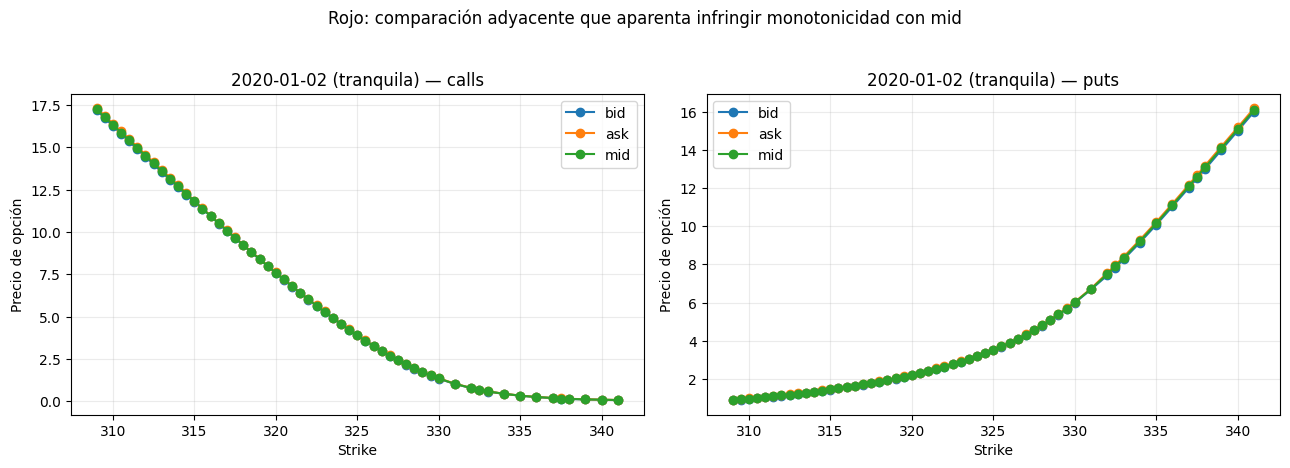

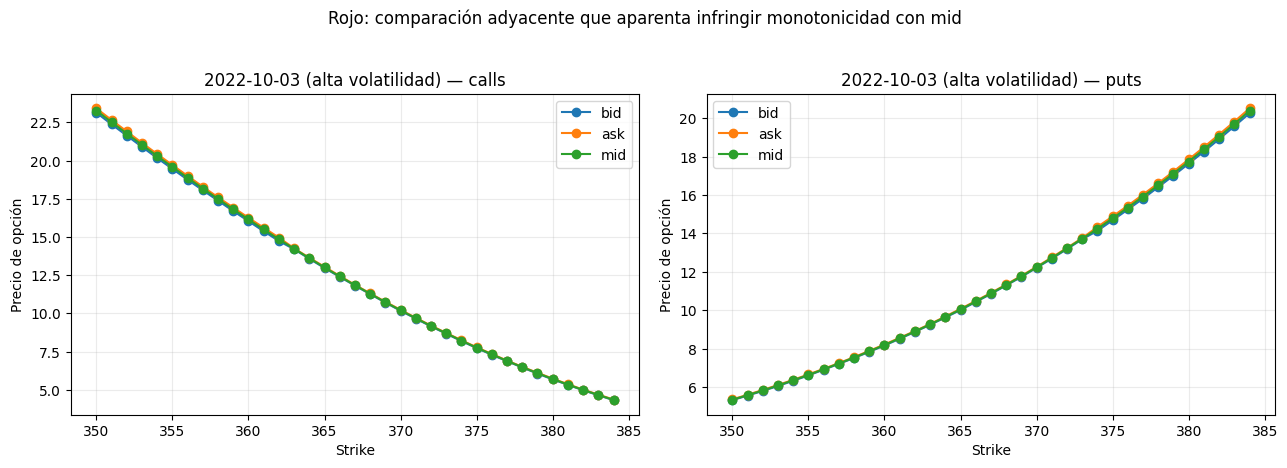

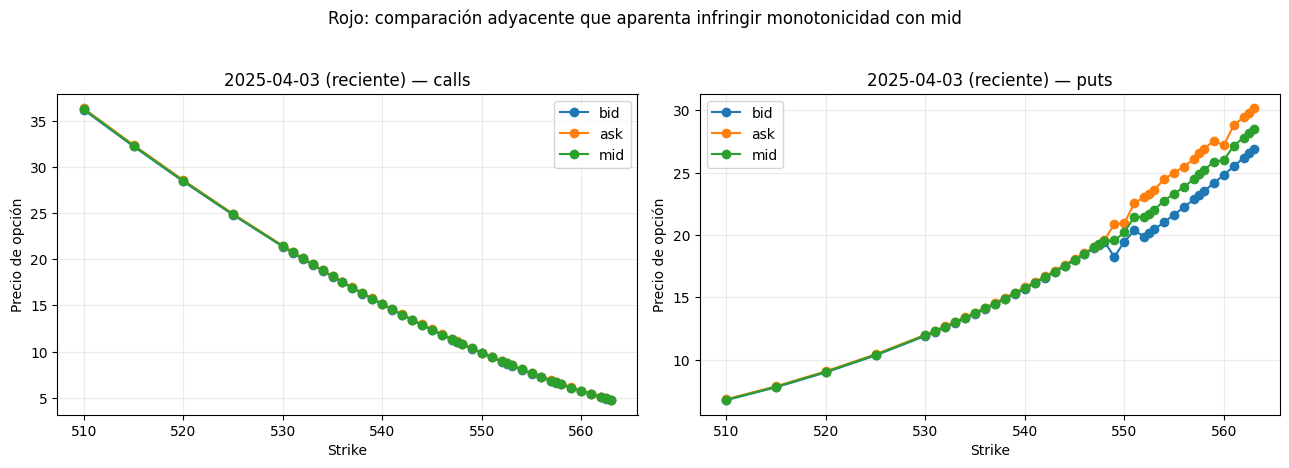

## Tres casos explicados

Solo aparecieron 0 casos de mid; se muestran todos, sin inventar un tercero.

## Interpretación final

De 0 aparentes infracciones de monotonicidad vistas con mid, 0 desaparecen al exigir bid/ask ejecutables y 0 persisten en esta muestra. Un mid es un promedio contable entre dos cotizaciones, no necesariamente un precio al que puedan comprarse y venderse ambas opciones. Esto es un diagnóstico de calidad y ejecutabilidad de cotizaciones; con hora de cotización no verificada y opciones americanas, no constituye una estrategia de arbitraje.

In [4]:
import matplotlib.pyplot as plt

# Dos gráficos por fecha: izquierda calls, derecha puts. Bid/ask se preservan como bandas ejecutables.
for chain_date in exercise_dates:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=False)
    for axis, option_type in zip(axes, ['call', 'put']):
        group = quotes_for_check.loc[(quotes_for_check['date'] == chain_date) & (quotes_for_check['type'] == option_type)].sort_values('strike')
        axis.plot(group['strike'], group['bid_num'], 'o-', label='bid', color='#1f77b4')
        axis.plot(group['strike'], group['ask_num'], 'o-', label='ask', color='#ff7f0e')
        axis.plot(group['strike'], group['mid_num'], 'o-', label='mid', color='#2ca02c')
        violations = apparent_cases.loc[(apparent_cases['date'] == chain_date) & (apparent_cases['type'] == option_type)]
        for _, violation in violations.iterrows():
            axis.plot([violation['lower_strike'], violation['higher_strike']], [violation['lower_mid'], violation['higher_mid']], color='crimson', linewidth=3, alpha=0.75)
        axis.set(title=f"{chain_date} ({exercise_labels[chain_date]}) — {option_type}s", xlabel='Strike', ylabel='Precio de opción')
        axis.grid(alpha=0.25)
        axis.legend()
    figure.suptitle('Rojo: comparación adyacente que aparenta infringir monotonicidad con mid', y=1.03)
    figure.tight_layout()
    plt.show()

# Tres casos para explicar manualmente: los primeros tres por fecha/tipo/strike entre las apariencias observadas.
manual_cases = apparent_cases.sort_values(['date', 'type', 'lower_strike', 'higher_strike']).head(3).copy()
display(Markdown('## Tres casos explicados'))
if len(manual_cases) < 3:
    display(Markdown(f'Solo aparecieron {len(manual_cases)} casos de mid; se muestran todos, sin inventar un tercero.'))
for number, (_, case) in enumerate(manual_cases.iterrows(), start=1):
    if case['type'] == 'call':
        mid_text = f"el mid de K={case['higher_strike']:.2f} ({case['higher_mid']}) supera al de K={case['lower_strike']:.2f} ({case['lower_mid']})"
        executable_test = f"bid alto {case['higher_bid']} {'>' if case['bid_ask_violation'] else '≤'} ask bajo {case['lower_ask']}"
    else:
        mid_text = f"el mid de K={case['higher_strike']:.2f} ({case['higher_mid']}) cae por debajo del de K={case['lower_strike']:.2f} ({case['lower_mid']})"
        executable_test = f"bid bajo {case['lower_bid']} {'>' if case['bid_ask_violation'] else '≤'} ask alto {case['higher_ask']}"
    verdict = 'persiste al considerar bid/ask' if case['bid_ask_violation'] else 'desaparece al considerar bid/ask'
    display(Markdown(f"**Caso {number}: {case['date']} — {case['type']}s, {case['expiration']}.** Con mid, {mid_text}. Con cotizaciones ejecutables, {executable_test}; por tanto, la apariencia **{verdict}**. ContractID: `{case['lower_contractID']}` frente a `{case['higher_contractID']}`."))

total_mid = int(summary_by_date_type['apparent_mid_violations'].sum())
total_persistent = int(summary_by_date_type['persistent_bid_ask_violations'].sum())
display(Markdown(
    f"## Interpretación final\n\nDe {total_mid} aparentes infracciones de monotonicidad vistas con mid, {total_mid - total_persistent} desaparecen al exigir bid/ask ejecutables y {total_persistent} persisten en esta muestra. Un mid es un promedio contable entre dos cotizaciones, no necesariamente un precio al que puedan comprarse y venderse ambas opciones. Esto es un diagnóstico de calidad y ejecutabilidad de cotizaciones; con hora de cotización no verificada y opciones americanas, no constituye una estrategia de arbitraje."
))